In [15]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set device (CUDA, MPS for Mac, or CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [16]:
data_path = "voice_features.csv"
df = pd.read_csv(data_path)
df.head()

,rms,centroid,bandwidth,label,file
0,0.064250,1370.322875,1552.798948,male,arctic_b0454.wav
1,0.076566,1398.934514,1343.242054,male,arctic_b0526(3).wav
2,0.063606,1794.079010,1593.002148,male,arctic_b0016(1).wav
3,0.099214,1193.246656,1501.137054,male,arctic_a0173(6).wav
4,0.048539,1932.585792,1561.053287,male,arctic_b0445(4).wav


In [17]:
# Separate features and labels
X = df.drop(['file', 'label'], axis=1)
y = df['label']

# Encode categorical labels ('male' / 'female') into numeric 0 / 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into training and testing sets (80/20 split, random_seed = 26 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, train_size=0.8, random_state=26)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Train set shape: (12918, 3)
Test set shape: (3230, 3)


In [18]:
# Custom Dataset for Voice Data
class VoiceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataset and DataLoader instances
train_dataset = VoiceDataset(X_train_scaled, y_train)
test_dataset = VoiceDataset(X_test_scaled, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
# Define the Neural Network Architecture
class VoiceGenderClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VoiceGenderClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
model = VoiceGenderClassifier(input_dim).to(device)
print(model)

VoiceGenderClassifier(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [20]:
# Define Loss function and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Training the model
EPOCHS = 40
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss:.4f}")

Epoch [1/40] - Loss: 0.5268
Epoch [5/40] - Loss: 0.4951
Epoch [10/40] - Loss: 0.4925
Epoch [15/40] - Loss: 0.4903
Epoch [20/40] - Loss: 0.4888
Epoch [25/40] - Loss: 0.4900
Epoch [30/40] - Loss: 0.4898
Epoch [35/40] - Loss: 0.4868
Epoch [40/40] - Loss: 0.4877


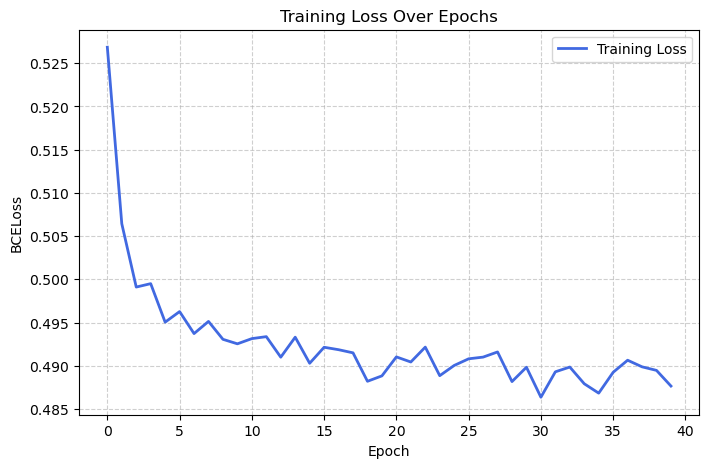

In [21]:
# Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', color='royalblue', linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCELoss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Test Accuracy: 75.29%

Classification Report:
              precision    recall  f1-score   support

      female       0.69      0.61      0.65      1212
        male       0.78      0.84      0.81      2018

    accuracy                           0.75      3230
   macro avg       0.74      0.73      0.73      3230
weighted avg       0.75      0.75      0.75      3230



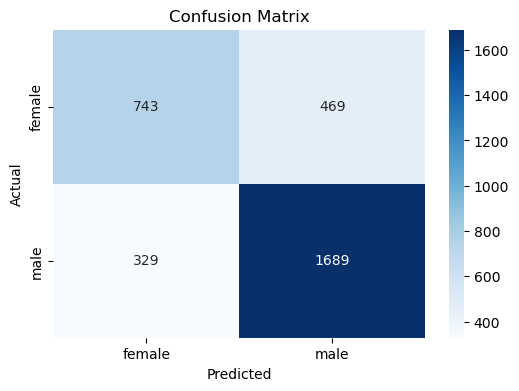

In [22]:
# Model Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        predictions = (outputs >= 0.5).float() # Convert probabilities to binary labels
        
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.numpy())

accuracy = accuracy_score(all_targets, all_preds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=le.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()